#  How to Handle Missing Values ?

Missing data is an unavoidable challenge in data science. Missing values in a dataset can be handled using two main strategies: **removing the missing data** or **imputing (filling in) the values**. Choosing the right strategy directly impacts our model's performance, especially in predictive tasks and variance, and production stability. 



---

## 1. Remove Them (Deletion / Complete Case Analysis)

Complete Case Analysis (CCA) involves removing rows or columns containing missing values entirely rather than trying to estimate. It means literally analyzing only those observations for which there is information in all of the variables in the dataset. This approach can be useful when there are no significant consequences of removing a particular observation


*   **What it is:** Deleting the incomplete entries from the dataset.

*   **Scikit-Learn Implementation:** No dedicated class. Use Pandas: `df.dropna(axis=0)` for rows or `df.dropna(axis=1)` for columns.

*   **When to Use:**
    *   The missing data is minimal (typically under 5%).
    *   The missingness is completely random (MCAR).(assumption that the data was collected randomly and without any pattern)
    *   A specific row is missing data across almost all targeted features.

*   **Risk / When to Avoid:**
    *   Dropping too much data destroys valuable training patterns and reduces final model accuracy.
    *   Avoid if the missingness is systematic (e.g., higher-income earners intentionally leaving salary fields blank), as deleting these rows introduces severe sample bias.

*   **Advantages:**
    *   It preserves the integrity of the dataset, reducing the risk of introducing bias in the final model.
    *   It preserve variable distribution(if data is MCAR) before and after removing missing values.
    *   It reduces the size of the dataset, making it easier to handle and train models.

*   **Disadvantages:**
    *   It can lead to loss of valuable information if the missing data is not random.
    *   It becomes difficult for the model at production to handle missing values.
    *   It can exclude the large fraction of original data (if missing data is not random)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Importing dataset
df = pd.read_csv('../../data/DataSciJob.csv')
print("Shape of the dataframe: ", df.shape)
df.head()

Shape of the dataframe:  (19158, 13)


,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


In [5]:
# Data information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  18679 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  float64
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  training_hours          18392 non-null  float64
 12  target                  19158 non-null  float64
dtypes: float64(4), int64(1), object(8)
memory usage: 1.9+ MB


In [6]:
# Missing values in each column(in percentage)
df.isnull().mean()*100

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

In [7]:
# Extracting columns that have missing values less than 5%
missing_col = [val for val in df.columns if df[val].isnull().mean() < 0.05 and df[val].isnull().mean() > 0]
print(f"Missing Columns Name : {missing_col}")

Missing Columns Name : ['city_development_index', 'enrolled_university', 'education_level', 'experience', 'training_hours']


In [8]:
# Check the columns containing missing values
df[missing_col].sample(5)

,city_development_index,enrolled_university,education_level,experience,training_hours
3283,0.830,no_enrollment,Masters,10.0,45.0
2836,0.698,no_enrollment,High School,8.0,20.0
6630,0.884,no_enrollment,Graduate,6.0,89.0
6991,0.740,no_enrollment,Graduate,0.0,88.0
12788,0.762,no_enrollment,Graduate,0.0,26.0


In [9]:
# Number of rows left after removing the missing values
info_left = len(df[missing_col].dropna() )/ len(df)* 100
print(f"Number of rows left after removing the missing values : {info_left:.2f}%")

Number of rows left after removing the missing values : 89.69%


In [10]:
# Make new copy of data frame containing only columns with missing values greater than 5%
new_df = df[missing_col].dropna()
print("Shape of the dataframe: ",new_df.shape)

Shape of the dataframe:  (17182, 5)


In [11]:
# Check the distribution 

def plot_dist(df, df_new, col):
    
    fig = plt.figure(figsize=(14,4))
    ax = fig.add_subplot(111)
    
    sns.histplot(data=df, x=col, kde=True, color='blue', alpha=0.7, bins=30, linewidth=1, label='Original Data')
    sns.histplot(data=df_new, x=col, kde=True, color='red', alpha= 0.7, bins=30, linewidth=1, label='Data with Missing Values')

    ax.set_title(f" Distribution of '{col}' " )
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.legend()
    plt.show
    



## 🧠 Understanding the Plots
- **Blue** = Original data (including missing values, which are excluded from the histogram)

- **Red** = Cleaned data (rows with no missing values in any of these columns)

### What it means when:

1. **Blue ≈ Red** → The missing values are Missing Completely at Random (MCAR). Removing them does not change the underlying distribution. No bias     introduced.

2. **Red > Blue** for a category → After deletion, that category becomes relatively more frequent. This suggests that rows with missing values were less likely to belong to that category – i.e., missingness is associated with lower values in that category.

3. **Red < Blue** for a category → After deletion, that category becomes less frequent. This implies rows with missing values were more likely to belong to that category – a potential source of bias.

The goal is to see if any substantial shifts occur that could compromise model performance or generalizability.

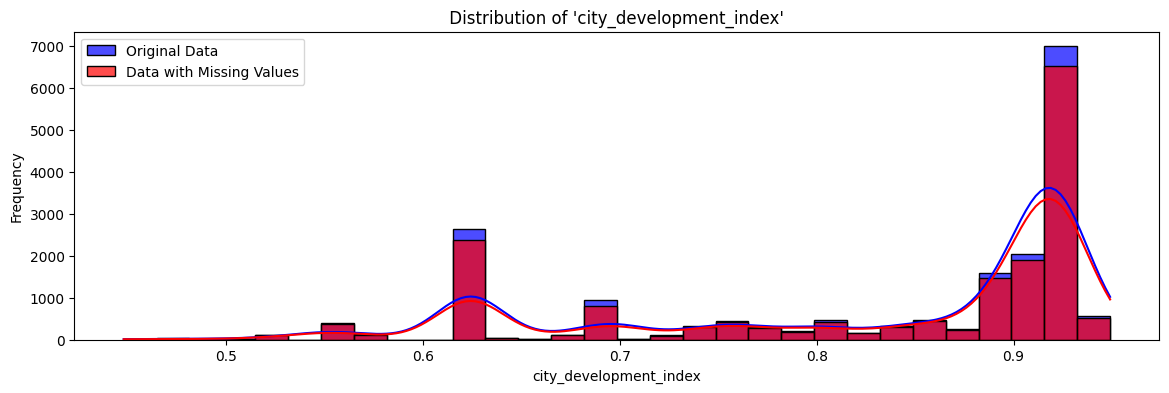

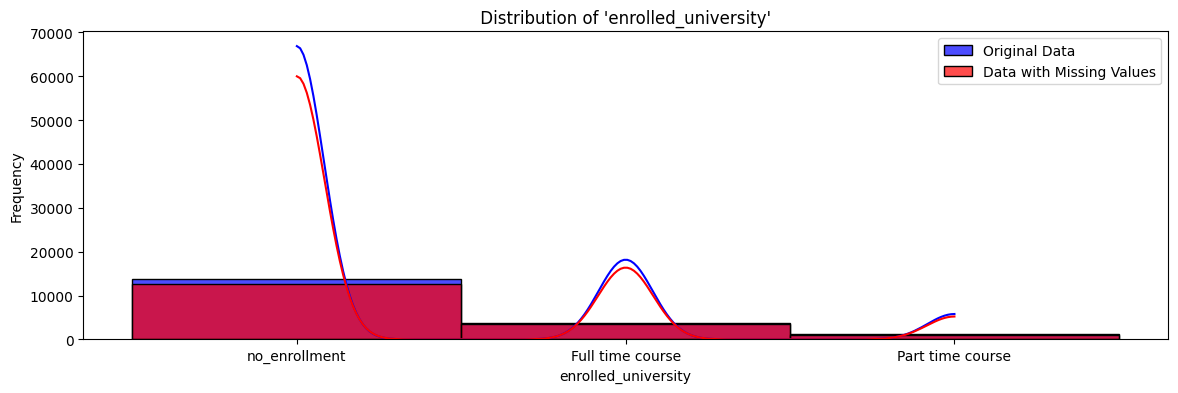

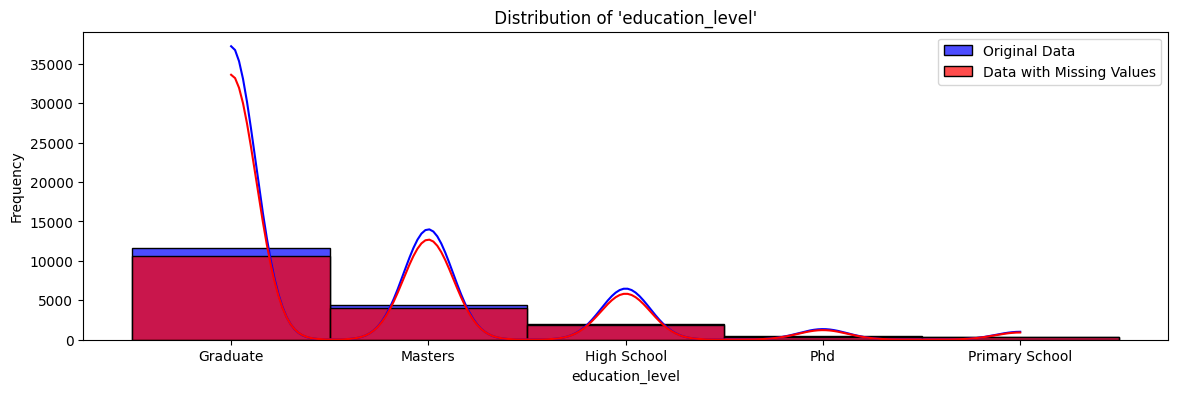

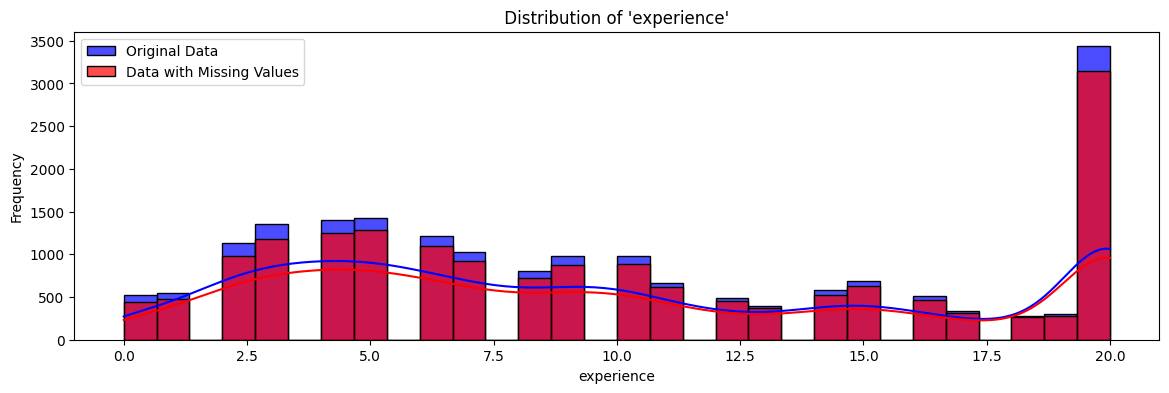

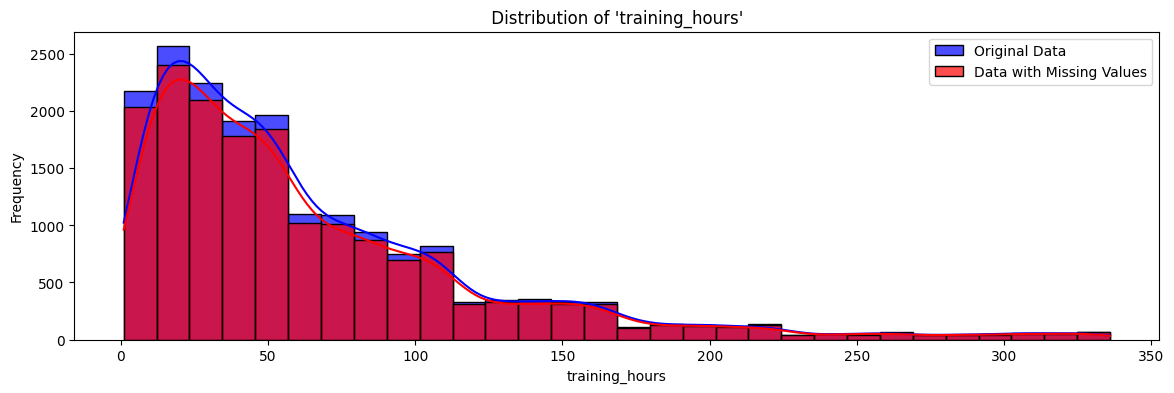

In [12]:
for col in missing_col:
    plot_dist(df, new_df, col)

In [13]:

## 📊 Effect of Removing Missing Values on Distribution
def effect_after_cca(df, new_df, col_name):
    """
    This function calculates the effect of removing missing values on the distribution of a categorical variable."""
    
    # Calculate the original distribution
    original_dist =  ( df[col_name].value_counts(normalize=False).sort_index() ) / len(df)
    
    # Calculate the distribution after removing missing values
    cleaned_dist = ( new_df[col_name].value_counts(normalize=False).sort_index() ) / len(new_df)
    
    # Calculate the difference in distribution
    effect = cleaned_dist - original_dist
    
    return effect

effect_after_cca(df, new_df, 'education_level')

education_level
Graduate          0.014448
High School       0.002097
Masters           0.006449
Phd               0.000506
Primary School    0.000510
Name: count, dtype: float64

## ✅ Final Recommendation

### Proceed with Complete Case Analysis (CCA)

- **Data retention:** 89.69% of rows remain after removing missing values.
- **Data loss:** Only 10.31% of the observations are removed, which is acceptable in this case.
- **Distribution change:** The maximum observed shift is less than `0.0005`, indicating negligible distortion.
- **Model impact:** Model performance and generalizability are unlikely to suffer substantially.

## 🧮 Summary of Results

| Aspect | Finding |
|---|---|
| **Data Retention** | 89.69% of rows remain after CCA; data loss is relatively low. |
| **Distribution Change** | Maximum distribution shift is `< 0.0005`, suggesting negligible bias. |
| **Missingness Pattern** | The results are consistent with the MCAR assumption for the analyzed columns. |
| **Conclusion** | CCA is a reasonable strategy for handling missing values in this dataset. |


> **Observation:** Although the distribution comparison supports using CCA, MCAR cannot be confirmed through visual inspection alone. The missingness mechanism should also be validated statistically or monitored during model evaluation.

### Practical Recommendation

Apply CCA only to the selected columns with low missingness, and compare the resulting model performance against an imputation-based approach before final deployment.